# Correction de biais multivariée pour les modèles climatiques

In [1]:
import importlib
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import functions


In [2]:
importlib.reload(functions)

<module 'functions' from 'c:\\Users\\gmass\\Desktop\\COURS_ENSAE\\2A\\statapp\\statapp_edf_25\\functions.py'>

## Introduction
Présentation du sujet, enjeux et problématique


## Présentation des données

### 1. Données de simulation CMIP6

Le projet CMIP6 (Coupled Model Intercomparison Project Phase 6) représente la dernière génération de modèles climatiques. On utilisera donc les bases de données associées à ce modèle plutôt que CMIP5 ou eurocordex. Les données sont divisées en deux périodes

- **CMIP6_historical** : simulations historiques de 1950 à 2015
- **CMIP6_ssp585** : projections futures de 2015 à 2100 selon le scénario SSP5-8.5 (scénario d'émissions élevées)

#### Variables CMIP6
- `date` : horodatage
- `tas` : température de l'air en surface (°C ou K)
- `sfcWind` : vitesse du vent en surface (m/s)
- `rlds` : rayonnement infrarouge descendant (longwave downward, W/m²)
- `rsds` : rayonnement solaire descendant (shortwave downward, W/m²)
- `huss` : humidité en surface (kg/kg)
- `uas` : composante horizontale du vent - direction est-ouest (m/s)
- `vas` : composante verticale du vent - direction nord-sud (m/s)

### 2. Données d'observation (obs)

Les observations réelles couvrent la période de **1982 à 2022** et constituent notre référence pour la correction des modèles.

#### Variables observées
- `date` : horodatage
- `tas` : température de l'air en surface (°C ou K)
- `uas` : composante zonale du vent - direction est-ouest (m/s)
- `vas` : composante méridionale du vent - direction nord-sud (m/s)
- `rsds` : rayonnement solaire descendant (W/m²)
- `rlds` : rayonnement infrarouge descendant (W/m²)
- `hurs` : humidité relative en surface (%)

### Différences entre CMIP6 et obs

- **CMIP6** inclut `sfcWind` (vitesse totale du vent) et `huss` (humidité spécifique)
- **obs** inclut `hurs` (humidité relative au lieu de spécifique)
- Les deux datasets partagent les composantes directionnelles du vent (`uas`, `vas`) et les rayonnements (`rsds`, `rlds`)

### Note sur l'humidité

L'humidité spécifique (`huss`) et l'humidité relative (`hurs`) sont deux mesures différentes :
- **huss** : masse de vapeur d'eau par unité de masse d'air (kg/kg)
- **hurs** : rapport entre la pression de vapeur actuelle et la pression de vapeur saturante (%)

Une conversion entre ces deux variables est possible si on connaît la température et la pression.


In [3]:
modele_hist = functions.csv_to_pd(r"data\CMIP6_historical.csv")
modele_futur = functions.csv_to_pd(r"data\CMIP6_ssp585.csv")

modele = pd.concat([modele_hist, modele_futur])
obs = functions.csv_to_pd(r"data\obs.csv")

modele_hist.head()


,date,tas,sfcWind,rlds,rsds,huss,uas,vas
0,1950-01-01,-1.686420,3.114002,303.704753,22.718583,3.576517,2.596141,0.765282
1,1950-01-02,-0.590311,4.385591,309.932332,7.131182,4.024346,3.865216,1.291576
2,1950-01-03,-0.063002,4.716338,314.250186,8.028077,4.192423,4.116754,1.296945
3,1950-01-04,-3.083886,3.500701,280.008345,30.872787,3.232979,2.438605,-1.731674
4,1950-01-05,-5.368538,2.403433,260.420616,50.302147,2.641278,-0.763190,-0.472883


In [4]:
modele.head()

,date,tas,sfcWind,rlds,rsds,huss,uas,vas
0,1950-01-01,-1.686420,3.114002,303.704753,22.718583,3.576517,2.596141,0.765282
1,1950-01-02,-0.590311,4.385591,309.932332,7.131182,4.024346,3.865216,1.291576
2,1950-01-03,-0.063002,4.716338,314.250186,8.028077,4.192423,4.116754,1.296945
3,1950-01-04,-3.083886,3.500701,280.008345,30.872787,3.232979,2.438605,-1.731674
4,1950-01-05,-5.368538,2.403433,260.420616,50.302147,2.641278,-0.763190,-0.472883


In [5]:
obs['year'] = obs['date'].dt.year
obs['month'] = obs['date'].dt.month

modele['year'] = modele['date'].dt.year
modele['month'] = modele['date'].dt.month   

## Existence de biais

En se focalisant sur la variable `tas`, on prend conscience du biais du modèle CMIP6

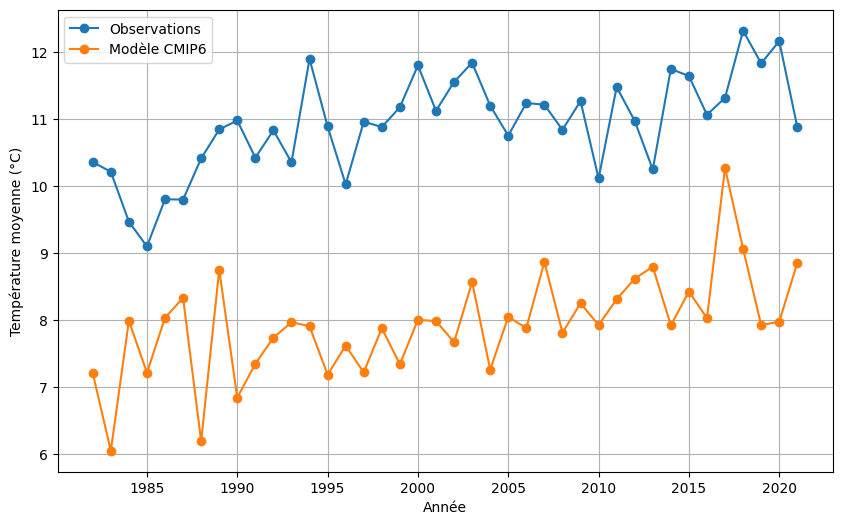

In [6]:
yobs = [obs[obs['year'] == m]['tas'].mean() for m in range(1982, 2022)]
ymodel = [modele[modele['year'] == m]['tas'].mean() for m in range(1982, 2022)]

plt.figure(figsize=(10, 6))
plt.grid()
plt.xlabel('Année')
plt.ylabel('Température moyenne (°C)')
plt.plot(range(1982, 2022), yobs, 'o-', label='Observations')
plt.plot(range(1982, 2022), ymodel, 'o-', label='Modèle CMIP6')
plt.legend()
plt.show()

On observe une augmentation globale dans le modèle comme dans les observations, avec une sous-évaluation de la variable `tas` par le modèle CMIP6

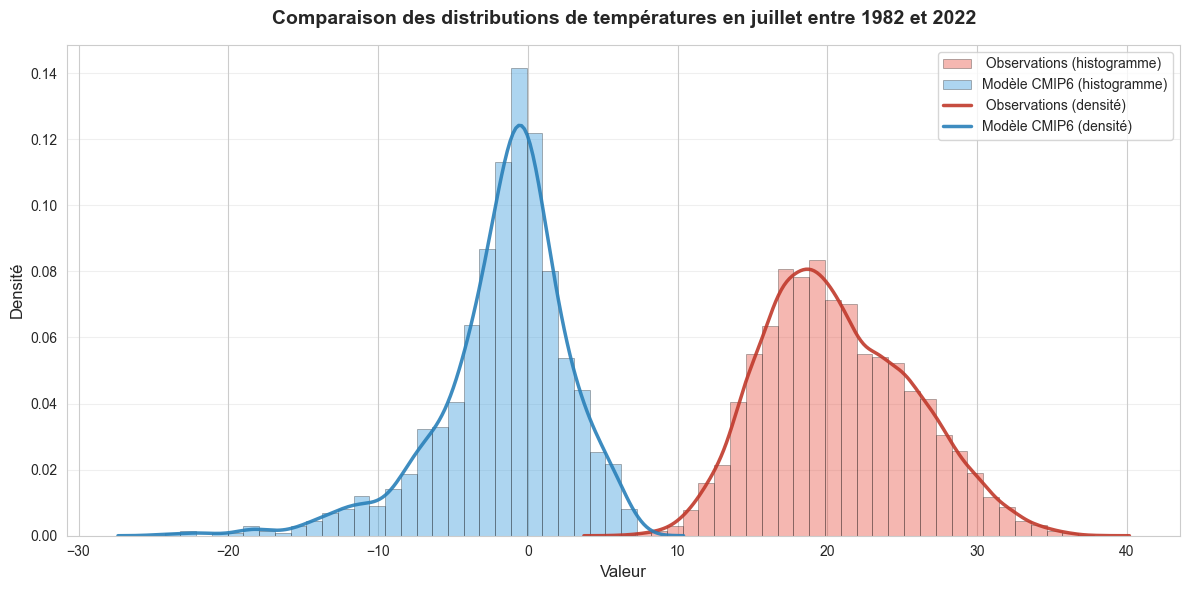

In [7]:
data1 = obs[obs['month'] == 7]['tas']
data2 = modele[modele['month'] == 7 & (modele['year'] >= 1982) & (modele['year'] <= 2022)]['tas']

functions.plot_distributions((data1, data2),
                             'Comparaison des distributions de températures en juillet entre 1982 et 2022',
                                ('Observations', 'Modèle CMIP6'))

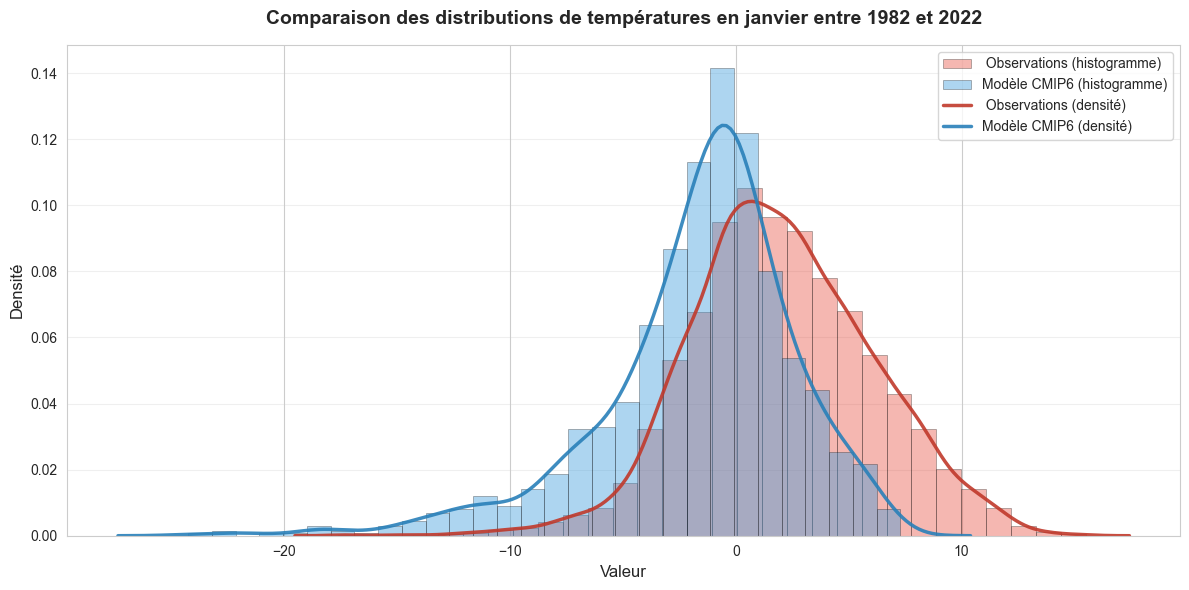

In [58]:
data1 = obs[obs['month'] == 1]['tas']
data2 = modele[modele['month'] == 1 & (modele['year'] >= 1982) & (modele['year'] <= 2022)]['tas']

functions.plot_distributions((data1, data2),
                             'Comparaison des distributions de températures en janvier entre 1982 et 2022',
                                ('Observations', 'Modèle CMIP6'))

Encore une fois, le modèle sous-évalue `tas` par rapport aux observations disponible. 

## Correction univariée du biais par quantile mapping

Le modèle CMIP6 a tendance a sous-évaluer `tas`, et il peut exister d'autres biais pour d'autres variables. Dans cette partie, nous allons tenter de corriger ces biais de façon univariée (variable par variable).

### Notations

On pose : 
- **$X_0$** : distribution du modèle dans le passé (période historique)
- **$X_1$** : distribution du modèle dans le futur (projections biaisées)
- **$Y_0$** : distribution des observations dans le passé
- **$Y_1$** : variable dont on cherche la distribution (projections non biaisées)


### Hypothèse de stationarité

Supposons que le biais entre le modèle et les observations passées est donnée par une transformation $T$ telle que 

$$F_{Y_0} = T \circ F_{X_0}$$

et que ce biais est stationnaire dans le temps, c'est à dire que l'on aura aussi dans le futur


$$F_{Y_1} = T \circ F_{X_1}$$

ce qui implique 

$$F_{Y_1} = F_{Y_0} \circ F_{X_0}^{-1} \circ F_{X_1}$$

Une fois que l'on a obtenu la fonction de répartition de $Y_1$, pour obtenir des réalisations $Y_1^i$ (observations futures corrigées), on utilise le **quantile mapping** :

$$Y_1^i = F_{Y_1}^{-1} \circ F_{X_1}(X_1^i)$$

où $X_1^i$ sont les valeurs du modèle futur.
<br><br>
En développant, on obtient :

$$Y_1^i = F_{X_1}^{-1} \circ F_{X_0} \circ F_{Y_0}^{-1} \circ F_{X_1}(X_1^i)$$


Les $Y_1^i$ sont donc sous l'hypothèse de stationnarité de meilleures projections que les $X_1^i$ issues du modèle **CMIP6**

## Tests de validité utilisant la variable `tas`
Dans un premier temps, on utilise comme données de correction les données du modèle et les observations entre 1982 et 2000 afin de comparer le modèle corrigé avec les observations de 2001 à 2022. 

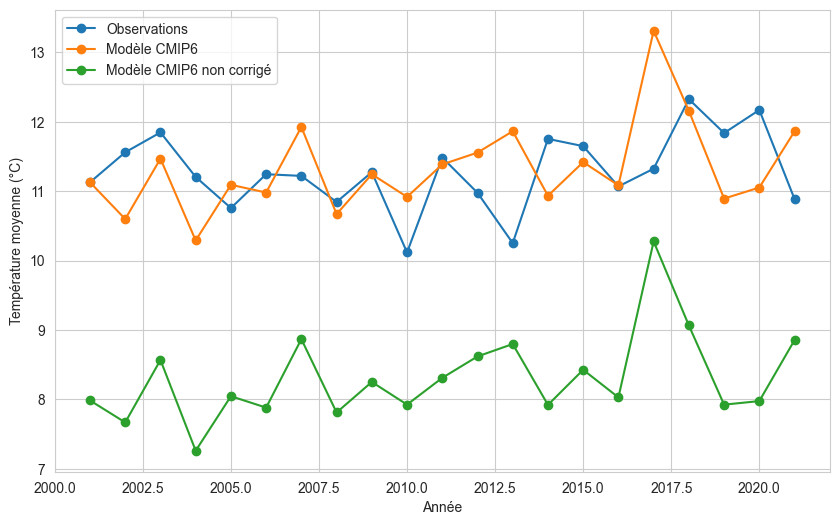

In [8]:
obs_to_2000 = obs[(obs['year'] >= 1982) & (obs['year'] <= 2000)]['tas'].values
modele_to_2000 = modele[(modele['year'] >= 1982) & (modele['year'] <= 2000)]['tas'].values
modele_from_2001 = modele[(modele['year'] >= 2001) & (modele['year'] <= 2022)]['tas'].values

modele_corrige, ecdf_modele_corrige = functions.cdf_t_univ(modele_to_2000, obs_to_2000, modele_from_2001)

df = pd.DataFrame({
    'valeurs_modele': modele_from_2001,
    'valeurs_corrigees': modele_corrige,
    'year': modele[(modele['year'] >= 2001) & (modele['year'] <= 2022)]['year'].values
})

tas_per_year_obs_2001_2022 = [obs[obs['year'] == m]['tas'].mean() for m in range(2001, 2022)]
tas_per_year_modele_corrige_2001_2022 = [df[df['year'] == m]['valeurs_corrigees'].mean() for m in range(2001, 2022)]
tas_per_year_modele_2001_2022 = [modele[modele['year'] == m]['tas'].mean() for m in range(2001, 2022)]

plt.figure(figsize=(10, 6))
plt.grid(True)
plt.xlabel('Année')
plt.ylabel('Température moyenne (°C)')
plt.plot(range(2001, 2022), tas_per_year_obs_2001_2022, 'o-', label='Observations')
plt.plot(range(2001, 2022), tas_per_year_modele_corrige_2001_2022, 'o-', label='Modèle CMIP6')
plt.plot(range(2001, 2022), tas_per_year_modele_2001_2022, 'o-', label='Modèle CMIP6 non corrigé')

plt.legend()
plt.show()

Le modèle corrigé correspond mieux aux observations. A une translation près, les courbes des modèles corrigé et non corrigé sont presque identiques (mais pas exactement). 

### Comparaison entre les deux modèles

On corrige maintenant le modèle sur toutes les observations disponibles

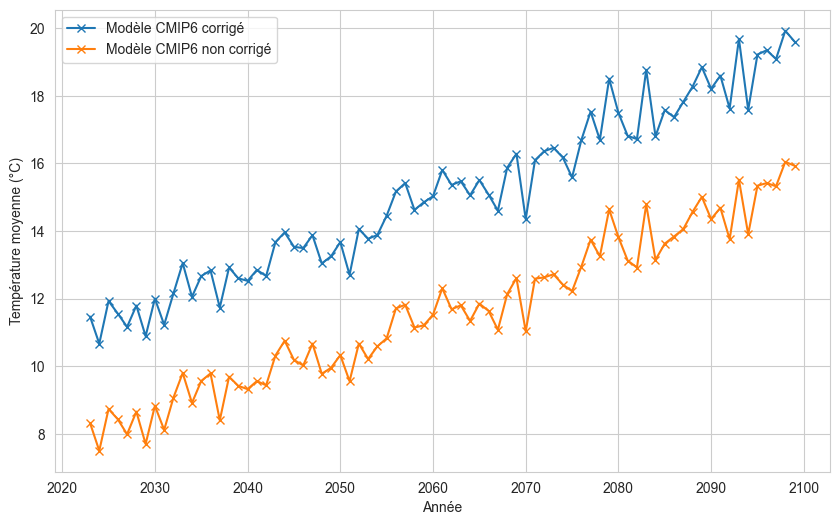

In [9]:
modele_to_2022 = modele[(modele['year'] >= 1982) & (modele['year'] <= 2022)]['tas'].values
modele_from_2023 = modele[(modele['year'] >= 2023) & (modele['year'] <= 2100)]['tas'].values

modele_corrige, ecdf_modele_corrige = functions.cdf_t_univ(modele_to_2022, obs['tas'].values, modele_from_2023)

df = pd.DataFrame({
    'valeurs_modele': modele_from_2023,
    'valeurs_corrigees': modele_corrige,
    'year': modele[(modele['year'] >= 2023) & (modele['year'] <= 2100)]['year'].values
})

tas_per_year_modele_corrige_2023_2100 = [df[df['year'] == m]['valeurs_corrigees'].mean() for m in range(2023, 2100)]
tas_per_year_modele_2023_2100 = [modele[modele['year'] == m]['tas'].mean() for m in range(2023, 2100)]

plt.figure(figsize=(10, 6))
plt.grid(True)
plt.xlabel('Année')
plt.ylabel('Température moyenne (°C)')
plt.plot(range(2023, 2100), tas_per_year_modele_corrige_2023_2100, 'x-', label='Modèle CMIP6 corrigé')
plt.plot(range(2023, 2100), tas_per_year_modele_2023_2100, 'x-', label='Modèle CMIP6 non corrigé')
plt.legend()
plt.show()


Pour mesurer à quel point la correction est une translation, on peut calculer l'écart-type du delta : 

In [10]:
delta = modele_corrige - modele_from_2023
std = np.std(delta)
moy = np.mean(delta)

print(f"Ecart type du delta = {std}")
print(f"Moyenne du delta = {moy}")


Ecart type du delta = 1.2436016602147988
Moyenne du delta = 3.507157859849912


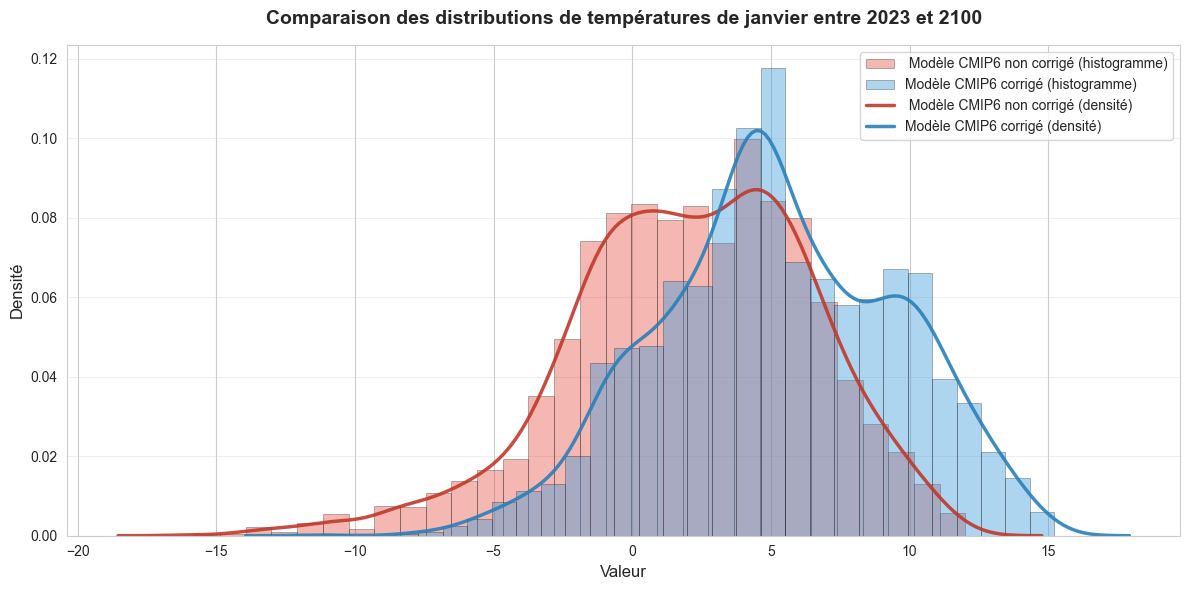

In [114]:

df2 = pd.DataFrame({
    'valeurs_modele': modele_from_2023,
    'valeurs_corrigees': modele_corrige,
    'year' : modele[(modele['year'] >= 2023) & (modele['year'] <= 2100)]['year'].values, 
    'month' : modele[(modele['year'] >= 2023) & (modele['year'] <= 2100)]['month'].values
})

functions.plot_distributions((np.array(df2[df2['month'] == 1]['valeurs_modele']), np.array(df2[df2['month'] == 1]['valeurs_corrigees'])),
                      'Comparaison des distributions de températures de janvier entre 2023 et 2100',
                        ('Modèle CMIP6 non corrigé', 'Modèle CMIP6 corrigé'))



In [118]:
functions.comparer_distributions_univ(np.array(df2[df2['month'] == 1]['valeurs_modele']), np.array(df2[df2['month'] == 1]['valeurs_corrigees']))

,Statistique,Distribution 1,Distribution 2
0,Moyenne,2.107,5.196
1,Médiane,2.327,5.006
2,Écart-type,4.363,4.284
3,Variance,19.036,18.353
4,Minimum,-15.790,-11.239
5,Maximum,12.014,15.224
6,Q1 (25%),-0.731,2.275
7,Q3 (75%),5.270,8.450
8,Étendue,27.804,26.464


## Validation théorique

On applique le quantile mapping a des variables de lois connues en générant $X_0$, $X_1$ et $Y_0$.

In [11]:
N = 10000

sigma_y0 = np.std(obs['tas'].values)
sigma_x0 = np.std(modele[modele['year'] <= 2022]['tas'].values)
sigma_x1 = np.std(modele[modele['year'] >= 2023]['tas'].values)

mu_y0 = np.mean(obs['tas'].values)
mu_x0 = np.mean(modele[modele['year'] <= 2022]['tas'].values)
mu_x1 = np.mean(modele[modele['year'] >= 2023]['tas'].values)


## on génère des lois normales

y0 = np.random.normal(mu_y0, sigma_y0, N)
x0 = np.random.normal(mu_x0, sigma_x0, N)
x1 = np.random.normal(mu_x1, sigma_x1, N)

## on applique la correction CDF-t

y1, _ = functions.cdf_t_univ(x0, y0, x1)

mu_Y1, sigma_y1, mu_th, sigma_th = np.mean(y1), np.std(y1), mu_x1 + (mu_y0 - mu_x0) * (sigma_x1 / sigma_x0), sigma_y0 * (sigma_x1 / sigma_x0)

print(f"Moyenne de la correction = {mu_Y1} ; Moyenne théorique = {mu_th}")
print(f"Ecart-type de la correction = {sigma_y1} ; Ecart-type théorique = {sigma_th}")

Moyenne de la correction = 15.751355001015481 ; Moyenne théorique = 15.507783801508086
Ecart-type de la correction = 9.075394744038714 ; Ecart-type théorique = 8.97985034088346


Les valeurs sont cohérentes

# Correction de biais dans le cas multi-dimensionnel